# Introducción a Agentic RAG

A diferencia de un RAG clásico (un único paso: query → recuperar → generar), un **Agentic RAG** delega al LLM la decisión de *cuándo*, *qué* y *cómo* consultar la base de conocimiento. El agente puede:

1. **Decidir si recuperar o no** — preguntas conversacionales no necesitan vector search.
2. **Calificar los documentos recuperados** — si no son relevantes, no responder con basura.
3. **Reescribir la pregunta** si la recuperación falló y volver a intentar.
4. **Generar la respuesta final** sólo cuando hay contexto útil.

Esto se modela naturalmente como un **grafo de estados** (LangGraph), donde cada nodo es una decisión o acción del agente.

```
       ┌─────────────────────────┐
START→ │ generate_query_or_respond│
       └─────────┬───────────────┘
                 │
        ┌────────┴─────────┐
        ▼                  ▼
   (sin tool_calls)    (tool_calls)
        │                  │
        ▼                  ▼
       END            ┌─────────┐
                      │retrieve │
                      └────┬────┘
                           │
                  ┌────────┴────────┐
                  ▼                 ▼
           grade=relevante    grade=irrelevante
                  │                 │
                  ▼                 ▼
         ┌───────────────┐  ┌────────────────┐
         │generate_answer│  │rewrite_question│
         └──────┬────────┘  └────────┬───────┘
                │                    │
                ▼                    └───→ vuelve a generate_query_or_respond
               END
```

Referencia: https://docs.langchain.com/oss/python/langgraph/agentic-rag


In [ ]:
# pip install langchain langgraph
# pip install langchain-openai langchain-community langchain-text-splitters
# pip install chromadb
# pip install sentence-transformers


In [2]:
import os
from typing import Literal

import langchain
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, convert_to_messages

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

from pydantic import BaseModel, Field
import chromadb

from dotenv import load_dotenv
load_dotenv()

openai_key = os.getenv("OPENAI_KEY")


In [13]:
# Mismo patrón de conexión que en el notebook anterior
llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-5.4-mini"),
    api_key=os.getenv("OPENAI_KEY"),
    temperature=0,  # 0 para que las decisiones del agente sean reproducibles
)

# Test rápido
llm.invoke("Di hola en una palabra").content


'Hola'

## 1. Preprocesamiento de documentos

Reusamos los `.txt` en `data/` (los mismos del RAG anterior: acta del CTO, política de devoluciones, specs de LR-100 y LR-200, comparativa, contactos, etc.) para poder comparar el comportamiento del Agentic RAG vs. el RAG simple sobre las **mismas** preguntas multi-hop.


In [6]:
all_txt_files = [i for i in os.listdir("data") if i.endswith(".txt")]
print(all_txt_files)

splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,        # un poco más grande que antes para que cada chunk tenga contexto suficiente
    chunk_overlap=10,
    separators=["\n\n", "\n", ". ", " ", ""],
)

all_chunks = []
all_ids = []
all_metas = []

for file in all_txt_files:
    with open(os.path.join("data", file), "r", encoding="utf-8") as f:
        document_i = f.read()
    chunks = splitter.split_text(document_i)
    all_chunks.extend(chunks)
    all_ids.extend([f"{file}_{i}" for i in range(len(chunks))])
    all_metas.extend([{"source": file} for _ in chunks])

print(f"Total chunks: {len(all_chunks)}")


['08_manual_uso_lr200.txt', '02_producto_lr200_specs.txt', '06_garantias.txt', '10_comparativa_competencia.txt', '03_politica_devoluciones_2023.txt', '07_soporte_contactos.txt', '05_acta_reunion_q3_2024.txt', '01_producto_lr100_specs.txt', '04_politica_devoluciones_2024.txt', '09_incidencias_conocidas.txt']
Total chunks: 130


## 2. Crear la herramienta de recuperación (`retriever_tool`)

Indexamos los chunks en ChromaDB (igual que antes) y luego envolvemos la búsqueda en una **tool** con el decorador `@tool`. Esa tool es lo que el LLM podrá invocar cuando *decida* que necesita consultar la base.


In [7]:
client = chromadb.Client()

# Limpieza si existe la colección
try:
    client.delete_collection(name="agentic-rag-docs")
except Exception:
    pass

collection = client.get_or_create_collection(
    name="agentic-rag-docs",
    metadata={"hnsw:space": "cosine"},
    # usa all-MiniLM-L6-v2 por defecto; se puede cambiar como en el notebook anterior
)

collection.add(
    documents=all_chunks,
    ids=all_ids,
    metadatas=all_metas,
)

print("Documentos indexados:", collection.count())


/Users/user/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:06<00:00, 12.3MiB/s]


Documentos indexados: 130


In [8]:
@tool
def retrieve_docs(query: str) -> str:
    """Busca información en la base de conocimiento de la empresa"""
    results = collection.query(
        query_texts=[query],
        n_results=4,  # hiper-parámetro por optimizar
    )
    docs = results["documents"][0]
    sources = [m["source"] for m in results["metadatas"][0]]
    # devolvemos texto plano con la fuente, así el LLM puede citar
    return "\n\n".join([f"[{s}] {d}" for s, d in zip(sources, docs)])

# Probar la tool directamente
print(retrieve_docs.invoke({"query": "autonomía LR-100"})[:500])


[10_comparativa_competencia.txt] Lumina LR-200 (referencia interna):
  Autonomía: 180 minutos

[10_comparativa_competencia.txt] Competidor A — modelo CleanX Pro
  Autonomía: 150 minutos

[09_incidencias_conocidas.txt] LR-100:

[10_comparativa_competencia.txt] Competidor B — modelo RoboNeat 5
  Autonomía: 200 minutos
  Mapeo: LiDAR combinado con cámara


## 3. Nodo `generate_query_or_respond`

Primer nodo del grafo. Recibe el historial de mensajes y decide:

- Si la pregunta requiere conocimiento de los documentos → emite un `tool_call` a `retrieve_docs`.
- Si es una pregunta conversacional (ej. *"hola"*) → responde directo y termina.

El truco está en `.bind_tools([retrieve_docs])`: el LLM ve la firma + docstring de la tool y decide.


In [14]:
response_model = llm  # reusamos el mismo LLM

def generate_query_or_respond(state: MessagesState):
    """Llama al modelo. El modelo decide si recuperar (tool_call) o responder directo."""
    response = response_model.bind_tools([retrieve_docs]).invoke(state["messages"])
    return {"messages": [response]}


In [15]:
# Caso 1: input conversacional → no debería usar la tool
input_1 = {"messages": [{"role": "user", "content": "Hola, ¿cómo estás?"}]}
out_1 = generate_query_or_respond(input_1)
out_1["messages"][-1].pretty_print()


================================== Ai Message ==================================

¡Hola! Estoy bien, gracias 😊 ¿Y tú, cómo estás?


In [16]:
# Caso 2: input que requiere RAG → debería emitir tool_call
input_2 = {"messages": [{"role": "user", "content": "¿Qué autonomía tiene el LR-100?"}]}
out_2 = generate_query_or_respond(input_2)
out_2["messages"][-1].pretty_print()


================================== Ai Message ==================================
Tool Calls:
  retrieve_docs (call_g9t1uu2OrTGDkgkCZMU2B3Av)
 Call ID: call_g9t1uu2OrTGDkgkCZMU2B3Av
  Args:
    query: LR-100 autonomía


## 4. Calificar documentos recuperados (`grade_documents`)

Un retriever puede devolver chunks que parecen relevantes por similitud coseno pero que no responden la pregunta. Antes de generar la respuesta, un LLM-juez decide en binario si el contexto es útil.

- **Sí** → ir a `generate_answer`.
- **No** → ir a `rewrite_question` y volver a intentar.

Usamos `with_structured_output` para forzar que la salida sea un schema Pydantic, no texto libre.


In [17]:
GRADE_PROMPT = (
    "Eres un evaluador que decide si un documento recuperado es relevante para la pregunta del usuario.\n"
    "Documento recuperado:\n\n{context}\n\n"
    "Pregunta del usuario: {question}\n"
    "Si el documento contiene información (literal o semánticamente relacionada) que ayude a responder la pregunta, "
    "califica como 'yes'. Si no, 'no'. Solo responde 'yes' o 'no'."
)


class GradeDocuments(BaseModel):
    """Calificación binaria de relevancia."""
    binary_score: str = Field(description="'yes' si es relevante, 'no' si no lo es")


grader_model = llm

def grade_documents(state: MessagesState) -> Literal["generate_answer", "rewrite_question"]:
    """Decide si los documentos recuperados son relevantes para la pregunta original."""
    question = state["messages"][0].content
    context = state["messages"][-1].content  # el último mensaje es el ToolMessage con los chunks

    prompt = GRADE_PROMPT.format(question=question, context=context)
    response = grader_model.with_structured_output(GradeDocuments).invoke(
        [{"role": "user", "content": prompt}]
    )
    if response.binary_score.lower() == "yes":
        return "generate_answer"
    else:
        return "rewrite_question"


In [19]:
# Test: contexto irrelevante → debe devolver 'rewrite_question'
test_irrelevante = {
    "messages": convert_to_messages([
        {"role": "user", "content": "¿Qué autonomía tiene el LR-100?"},
        {"role": "assistant", "content": "", "tool_calls": [
            {"id": "1", "name": "retrieve_docs", "args": {"query": "autonomía LR-100"}}
        ]},
        {"role": "tool", "content": "miau miau receta de pollo", "tool_call_id": "1"},
    ])
}
print("Contexto irrelevante →", grade_documents(test_irrelevante))


Contexto irrelevante → rewrite_question


## 5. Reescribir la pregunta (`rewrite_question`)

Cuando el grader dice que el contexto no sirve, asumimos que la pregunta original estaba mal formulada para nuestro retriever (vocabulario distinto al de los documentos, ambigua, etc.). Pedimos al LLM que la reformule preservando la intención semántica.


In [20]:
REWRITE_PROMPT = (
    "Mira la pregunta original e intenta razonar sobre la intención semántica subyacente.\n"
    "Pregunta original:\n-------\n{question}\n-------\n"
    "Formula una versión mejorada de la pregunta, en español, conservando la intención. "
    "Sé específico con nombres de modelos, fechas y términos técnicos si los hay."
)

def rewrite_question(state: MessagesState):
    """Reformula la pregunta original del usuario."""
    question = state["messages"][0].content
    prompt = REWRITE_PROMPT.format(question=question)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [HumanMessage(content=response.content)]}


## 6. Generar la respuesta (`generate_answer`)

Si pasamos el grader, usamos la pregunta original + los chunks recuperados para generar la respuesta final. Aquí no es necesario que el modelo decida nada más: solo redactar.


In [21]:
GENERATE_PROMPT = (
    "Eres un asistente para tareas de pregunta-respuesta sobre la documentación interna de la empresa. "
    "Usa ÚNICAMENTE los siguientes fragmentos del contexto para responder. "
    "Si la respuesta no está en el contexto, di que no lo sabes; no inventes. "
    "Sé conciso (máximo 3 oraciones) y, si es posible, cita la fuente entre corchetes.\n"
    "Pregunta: {question}\n"
    "Contexto:\n{context}"
)

def generate_answer(state: MessagesState):
    """Genera la respuesta final basada en el contexto recuperado."""
    question = state["messages"][0].content
    context = state["messages"][-1].content
    prompt = GENERATE_PROMPT.format(question=question, context=context)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [response]}


## 7. Ensamblar el grafo

Conectamos todo:

- `START` → `generate_query_or_respond`
- Si emitió `tool_calls` → `retrieve` (nodo `ToolNode` que ejecuta `retrieve_docs`); si no → `END`.
- Después de `retrieve` → `grade_documents` decide entre `generate_answer` (relevante) o `rewrite_question` (no relevante).
- `rewrite_question` → vuelve a `generate_query_or_respond` (loop).
- `generate_answer` → `END`.

`tools_condition` es un helper de LangGraph que mira el último mensaje y enruta a `"tools"` si hay `tool_calls`, o a `END` si no.


In [22]:
workflow = StateGraph(MessagesState)

# Nodos
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retrieve_docs]))
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("generate_answer", generate_answer)

# Aristas
workflow.add_edge(START, "generate_query_or_respond")

workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,
    },
)

workflow.add_conditional_edges(
    "retrieve",
    grade_documents,  # devuelve "generate_answer" o "rewrite_question"
)

workflow.add_edge("generate_answer", END)
workflow.add_edge("rewrite_question", "generate_query_or_respond")

graph = workflow.compile()


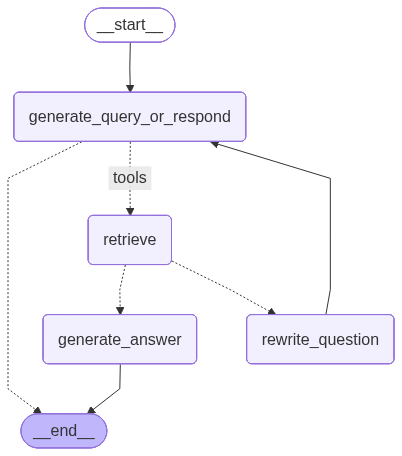

In [23]:
# Visualización del grafo (requiere graphviz/mermaid; si falla, ignorar)
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("No se pudo renderizar el grafo:", e)
    print(graph.get_graph().draw_ascii())


## 8. Ejecutar el Agentic RAG

Probamos con la pregunta multi-hop del notebook anterior:

> *"¿Qué autonomía tiene el modelo que el CTO recomendó discontinuar?"*

Cadena esperada: el agente busca en el acta → encuentra que el CTO recomienda discontinuar el LR-100 → busca specs del LR-100 → responde **90 minutos**.


In [24]:
pregunta = "¿Qué autonomía tiene el modelo que el CTO recomendó discontinuar?"

for chunk in graph.stream({"messages": [{"role": "user", "content": pregunta}]}):
    for node, update in chunk.items():
        print(f"=== Update desde nodo: {node} ===")
        update["messages"][-1].pretty_print()
        print()


=== Update desde nodo: generate_query_or_respond ===
================================== Ai Message ==================================
Tool Calls:
  retrieve_docs (call_4e7iuIVK5tgAANwgeE8BPcz7)
 Call ID: call_4e7iuIVK5tgAANwgeE8BPcz7
  Args:
    query: CTO recomendó discontinuar modelo autonomía recomendado discontinuar modelo

=== Update desde nodo: retrieve ===
================================= Tool Message =================================
Name: retrieve_docs

[10_comparativa_competencia.txt] Competidor A — modelo CleanX Pro
  Autonomía: 150 minutos

[09_incidencias_conocidas.txt] . No hay solución prevista; el modelo está en proceso de discontinuación.

[05_acta_reunion_q3_2024.txt] . Tras revisar las incidencias acumuladas en el último año, recomienda discontinuar el modelo LR-100

[10_comparativa_competencia.txt] Competidor B — modelo RoboNeat 5
  Autonomía: 200 minutos
  Mapeo: LiDAR combinado con cámara

=== Update desde nodo: generate_answer ===
===============================

In [25]:
# Otra pregunta: temporal/condicional
pregunta_2 = "Compré un LR-200 sin abrir hace 45 días, ¿puedo devolverlo y con qué cargo?"

for chunk in graph.stream({"messages": [{"role": "user", "content": pregunta_2}]}):
    for node, update in chunk.items():
        print(f"=== Update desde nodo: {node} ===")
        update["messages"][-1].pretty_print()
        print()


=== Update desde nodo: generate_query_or_respond ===
================================== Ai Message ==================================
Tool Calls:
  retrieve_docs (call_uPtL4Ui5wPcJQolcaNQXUAo7)
 Call ID: call_uPtL4Ui5wPcJQolcaNQXUAo7
  Args:
    query: política de devoluciones LR-200 sin abrir 45 días cargo devolución reembolso

=== Update desde nodo: retrieve ===
================================= Tool Message =================================
Name: retrieve_docs

[04_politica_devoluciones_2024.txt] Estado del producto:
- Sin abrir: reembolso íntegro, sin cargos adicionales.

[03_politica_devoluciones_2023.txt] Gastos de envío de la devolución: a cargo del cliente, salvo en caso de defecto de fábrica.

[03_politica_devoluciones_2023.txt] Reembolso: en el método de pago original, entre 7 y 10 días laborables tras recibir la devolución.

[04_politica_devoluciones_2024.txt] - Abierto y en buen estado: reembolso íntegro si se devuelve en los primeros 30 días.

=== Update desde nodo: genera

In [26]:
# Y una conversacional (NO debería invocar la tool)
pregunta_3 = "Hola, ¿qué tal?"

for chunk in graph.stream({"messages": [{"role": "user", "content": pregunta_3}]}):
    for node, update in chunk.items():
        print(f"=== Update desde nodo: {node} ===")
        update["messages"][-1].pretty_print()
        print()


=== Update desde nodo: generate_query_or_respond ===
================================== Ai Message ==================================

¡Hola! Muy bien, gracias. ¿En qué puedo ayudarte hoy?



# Tarea en clase

Compara el desempeño del **RAG simple** (notebook anterior) vs. el **Agentic RAG** (este notebook) sobre las mismas preguntas:

1. *"¿Qué versión de la app necesito para el modelo que reemplazó al LR-100?"* (multi-hop)
2. *"Mi LR-200 muestra error E07 que no se va al reiniciar, ¿a quién llamo?"* (routing)
3. *"¿Qué modelo del mercado ofrece mejor garantía por menos de 600 €?"* (comparación cruzada)
4. *"Lista todos los bugs de software del modelo estrella que ya estén resueltos."* (agregación con filtrado)

**Discusión:**

- ¿En qué preguntas el agentic ayuda y en cuáles no aporta sobre el RAG simple?
- ¿Cuántas llamadas al LLM hace cada uno?
- ¿Qué pasa si subes/bajas `n_results` en la tool? ¿Y `chunk_size`?
- Modifica el `GRADE_PROMPT` para ser más estricto. ¿Mejora o empeora la precisión final?

# Referencias

LangChain (2024). *Build a custom RAG agent with LangGraph*. https://docs.langchain.com/oss/python/langgraph/agentic-rag